In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns 

import matplotlib.font_manager as fm
import polars as pl 

In [2]:
sns.set_context('paper', font_scale=2)
sns.set_style('whitegrid')
try:
    fm.fontManager.addfont('/Users/krasowski/Library/Fonts/LibertinusSerif-Regular.ttf')
    sns.set_theme(font='Libertinus Serif')  
    mpl.rcParams['mathtext.fontset'] = 'custom'
    mpl.rcParams['mathtext.rm'] = 'Libertinus Serif'
    mpl.rcParams['mathtext.it'] = 'Libertinus Serif:italic'
    mpl.rcParams['mathtext.bf'] = 'Libertinus Serif:bold'
    mpl.rcParams['text.usetex'] = True
    mpl.rcParams['font.family'] = 'serif'
    mpl.rcParams['font.serif'] = ['Libertinus Serif']
except Exception as e:
    print(f"Could not set custom font: {e}")

In [3]:
df = pl.read_csv("../results/all_experiments_results_float64.csv")

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl

# ── Configuration ──────────────────────────────────────────────────────────
problems = ['poisson_1d', 'poisson_2d', 'heat', 'drift_diffusion', 'wave']
problem_labels = ['Poisson 1D', 'Poisson 2D', 'Heat', 'Drift-Diffusion', 'Wave']
# filter grids - set to None to include all 
GRID_FILTER = None
# GRID_FILTER = [8, 16, 32, 64, 128, 256]  

def get_filtered_df(df, problem, metric, n_iter, num_domain=10_000):
    df = df.filter(pl.col('seed') < 10)
    if problem == 'poisson_1d':
        filtered = df.filter(
            (pl.col('problem') == problem) &
            (pl.col('n_iterations') == n_iter) &
            (pl.col('num_domain') == num_domain)
        )
    elif problem == 'poisson_2d':
        filtered = df.filter(
            (pl.col('problem') == problem) &
            (pl.col('n_iterations') == n_iter) &
            (pl.col('num_domain') == num_domain) &
            (pl.col('nx') == pl.col('ny')) 
        )
    else:
        filtered = df.filter(
            (pl.col('problem') == problem) &
            (pl.col('n_iterations') == n_iter) &
            (pl.col('num_domain') == num_domain) &
            (pl.col('nx') == pl.col('nt')) 
        )
    return filtered.select(pl.col(metric), pl.col('nx')).to_pandas()
    # val = filtered.select(pl.col(metric).mean()).to_pandas().iloc[0, 0]
    # return val if (val is not None and not np.isnan(val)) else None


def get_equal_grids(df, problem):
    """Get all equally-spaced grid sizes available for a problem."""
    if problem == 'poisson_1d':
        sizes = df.filter(
            (pl.col('problem') == problem) &
            (pl.col('num_domain') == 10_000)
        ).select('nx').unique().sort('nx')['nx'].to_list()
    elif problem == 'poisson_2d':
        sizes = df.filter(
            (pl.col('problem') == problem) &
            (pl.col('num_domain') == 10_000) &
            (pl.col('nx') == pl.col('ny'))
        ).select('nx').unique().sort('nx')['nx'].to_list()
    else:
        sizes = df.filter(
            (pl.col('problem') == problem) &
            (pl.col('num_domain') == 10_000) &
            (pl.col('nx') == pl.col('nt'))
        ).select('nx').unique().sort('nx')['nx'].to_list()

    if GRID_FILTER is not None:
        sizes = [s for s in sizes if s in GRID_FILTER]
    return sizes


# ── Plotting ───────────────────────────────────────────────────────────────
def plot_convergence(df, save_path=None):
    fig, axes = plt.subplots(1, 5, figsize=(16, 3.2), sharey=False)

    configs = {
        "e_fdm": {
            'metric': 'e_fdm_vs_true_l2',
            'label': r'$e_{\mathrm{FDM}}$',
            'linestyle': '-',
            'marker': 'o',
            'alpha': 1.0,
            'color': 'red',
            'num_domain': 10_000,
            'n_iter': 10_000,
        },
        "e_res_good": {
            'metric': 'e_res_vs_true_l2',
            'label': r'$e_{\mathrm{res}}$ (well-trained)',
            'linestyle': '-',
            'marker': 'o',
            'alpha': 1.0,
            'color': 'blue',
            'num_domain': 10_000,
            'n_iter': 10_000,
        },
        "e_res_random": {
            'metric': 'e_res_vs_true_l2',
            'label': r'$e_{\mathrm{res}}$ (random init)',
            'linestyle': '--',
            'marker': 's',
            'alpha': 1.0,
            'color': 'blue',
            'num_domain': 10_000,
            'n_iter': 0,
        },
        "e_res_overfit": {
            'metric': 'e_res_vs_true_l2',
            'label': r'$e_{\mathrm{res}}$ (overfit)',
            'linestyle': ':',
            'marker': 'X',
            'alpha': 1.0,
            'color': 'blue',
            'num_domain': 10,
            'n_iter': 10_000, 
        },
    }

    for ax, problem, label in zip(axes, problems, problem_labels):
        grid_sizes = get_equal_grids(df, problem)
        if not grid_sizes:
            ax.set_title(label)
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            continue

        for config_name in ['e_fdm', 'e_res_good', 'e_res_random']:
            config = configs[config_name]
            metric = config['metric']
            n_iter = config['n_iter']
            num_domain = config['num_domain']

            df_filtered = get_filtered_df(df, problem, metric, n_iter, num_domain)
            if df_filtered.shape[0] > 0:
                sns.lineplot(
                    data=df_filtered,
                    x='nx', 
                    y=metric,
                    ax=ax,
                    color=config['color'],
                    linestyle=config['linestyle'],
                    marker=config['marker'],
                    markersize=4,
                    linewidth=1.5,
                    alpha=config['alpha'],
                    errorbar='sd'
                )

        ax.set_title(label)
        ax.set_xlabel('Grid size $N \\times N$', fontsize=9)
        ax.set_yscale('log')
        ax.set_xscale('log', base=2)
        ax.set_xticks(grid_sizes)
        ax.set_xticklabels(grid_sizes)
        ax.tick_params(labelsize=8)
        ax.set_ylabel(None)

    axes[0].set_ylabel('Error (L² norm)', fontsize=9)

    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved to {save_path}")

    return fig


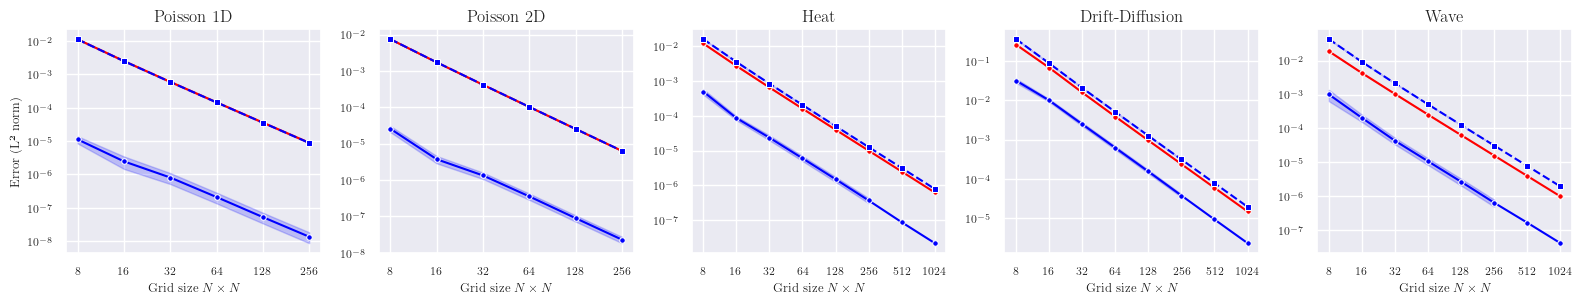

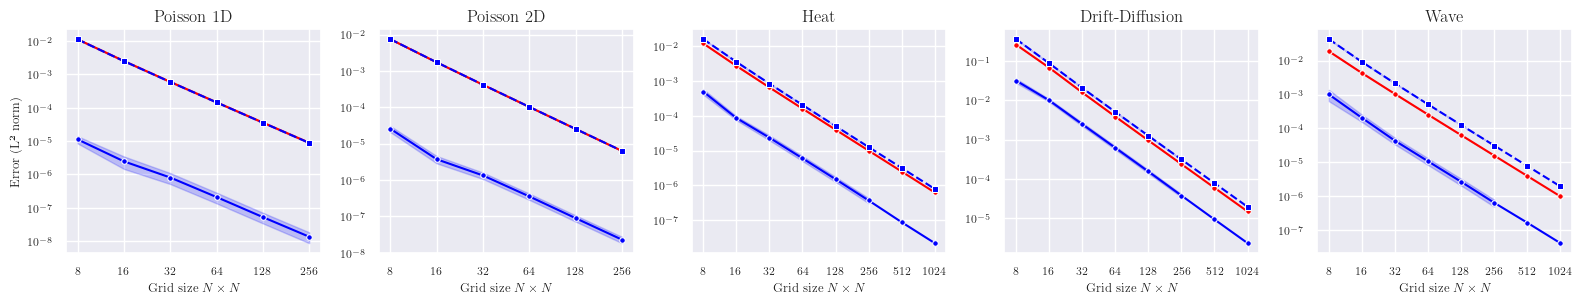

In [5]:
plot_convergence(df)

In [6]:
def plot_results(df, problem_name):
    num_domains = [1, 10, 100, 1000, 10000]
    df = df.filter(pl.col("problem") == problem_name)

    fig, axes = plt.subplots(ncols=len(num_domains), figsize=(5*len(num_domains), 5))

    for i, num_domain in enumerate(num_domains):
        ax = axes[i]
        df_n = df.filter(pl.col("num_domain") == num_domain, pl.col('seed') == 0)
        if problem_name in ['poisson_2d']:
            df_n = df_n.filter(pl.col('nx') == pl.col('ny'))
        elif problem_name in ['heat', 'drift_diffusion', 'wave']:
            df_n = df_n.filter(pl.col('nx') == pl.col('nt'))
        else:
            pass 

        for e, n_iterations in enumerate([0, 10000]):
            df_plot = df_n.filter(pl.col("n_iterations") == n_iterations).sort("nx")
            alpha = 1 / (e + 1)
            label_est = "Uncertainty (ours)" if e == 0 else None
            label_fdm = "Uncertainty FDM" if e == 0 else None
            ax.plot(df_plot["nx"], df_plot["e_res_vs_true_l2"], label=label_est, c='b', alpha=alpha, marker='o')
            ax.plot(df_plot["nx"], df_plot["e_fdm_vs_true_l2"], label=label_fdm, c='g', alpha=alpha, marker='o')

        ax.set_xscale('log', base=2)
        ax.set_yscale('log')
        ax.set_title(f"N={num_domain}")
        ax.set_xlabel("Grid size (nx=nt)")
        ax.set_ylabel("L2 Error")
        ax.legend()

    fig.suptitle(f"{problem_name} Equation")

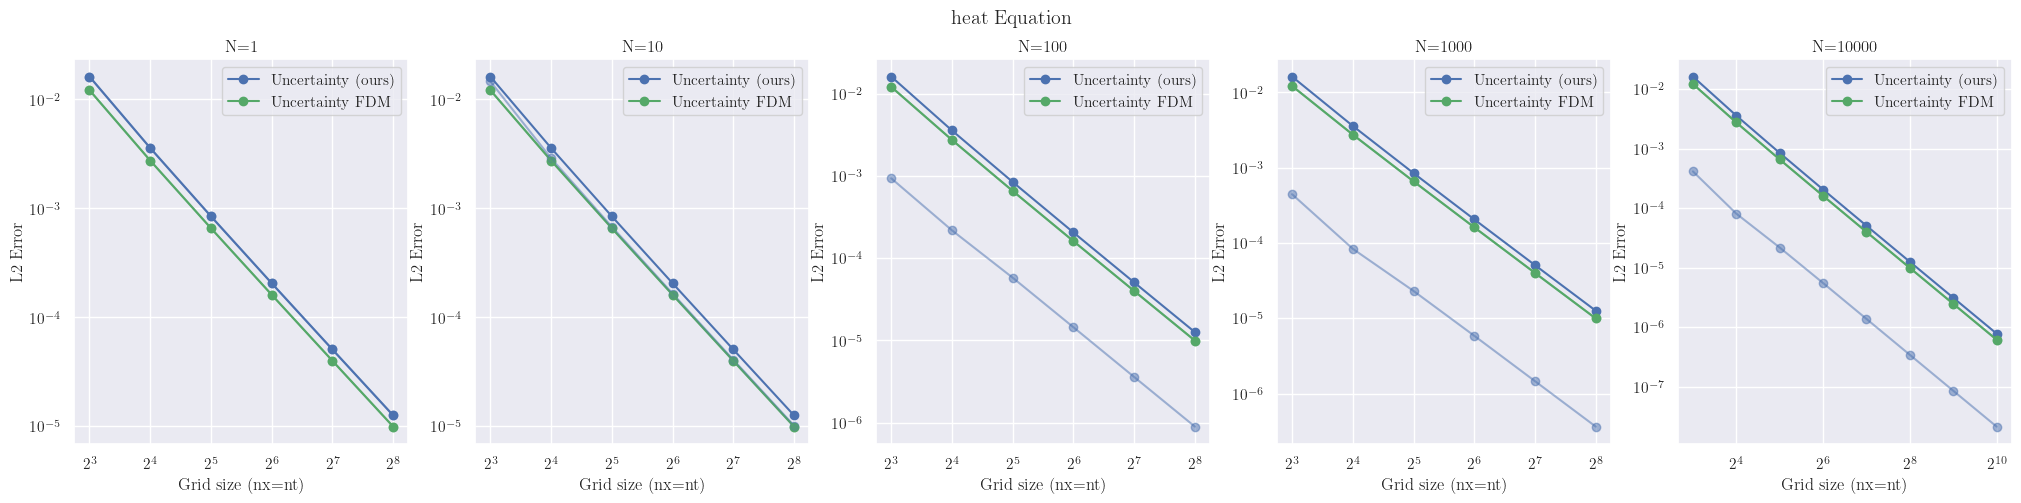

In [7]:
plot_results(df, "heat")

In [8]:
df.filter(pl.col('problem') == 'wave')

problem,nx,nt,ny,n_iterations,num_domain,seed,pinn_time,fdm_time,residual_estimation_time,stability_flag,pinn_error_l2,pinn_error_relative_l2,e_res_vs_true_l2,e_res_vs_true_relative_l2,e_fdm_vs_true_l2,e_fdm_vs_true_relative_l2,prob_x_min,prob_x_max,prob_t_max,prob_diffusivity,prob_frequency,prob_velocity_x,prob_phase_shift,prob_propagation_speed,prob_initital_concentration,prob_y_min,prob_y_max
str,i64,i64,i64,i64,i64,i64,f64,f64,f64,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""wave""",16,16,16,0,1000,3,0.002979,0.000062,0.008691,false,0.84734,1.697999,0.009198,0.010855,0.004322,0.005101,0.0,1.0,1.0,0.05,2.0,2.0,0.0,0.5,1.0,0.0,1.0
"""wave""",64,64,16,0,1,7,0.002152,0.00018,0.031853,false,0.871958,1.74413,0.000513,0.000589,0.000256,0.000293,0.0,1.0,1.0,0.05,2.0,2.0,0.0,0.5,1.0,0.0,1.0
"""wave""",8,8,16,10000,100,6,12.876086,0.000026,0.003275,false,0.131206,0.264487,0.422486,3.220014,0.018958,0.144491,0.0,1.0,1.0,0.05,2.0,2.0,0.0,0.5,1.0,0.0,1.0
"""wave""",64,64,16,10000,100,6,12.876086,0.000182,0.036333,false,0.132107,0.264247,0.000797,0.006032,0.000256,0.001935,0.0,1.0,1.0,0.05,2.0,2.0,0.0,0.5,1.0,0.0,1.0
"""wave""",256,256,16,10000,0,0,0.003214,0.000857,0.225916,false,0.866631,1.733275,0.000031,0.000036,0.000016,0.000018,0.0,1.0,1.0,0.05,2.0,2.0,0.0,0.5,1.0,0.0,1.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""wave""",64,64,16,10000,1000,4,28.517895,0.00018,0.032201,false,0.000395,0.000791,0.000011,0.028385,0.000256,0.646708,0.0,1.0,1.0,0.05,2.0,2.0,0.0,0.5,1.0,0.0,1.0
"""wave""",8,8,16,10000,1000,0,28.052139,0.000027,0.003294,false,0.001236,0.002491,0.000754,0.610442,0.018958,15.339073,0.0,1.0,1.0,0.05,2.0,2.0,0.0,0.5,1.0,0.0,1.0
"""wave""",256,256,16,10000,10,0,12.484608,0.000853,0.203979,false,0.416647,0.833301,0.000027,0.000064,0.000016,0.000038,0.0,1.0,1.0,0.05,2.0,2.0,0.0,0.5,1.0,0.0,1.0


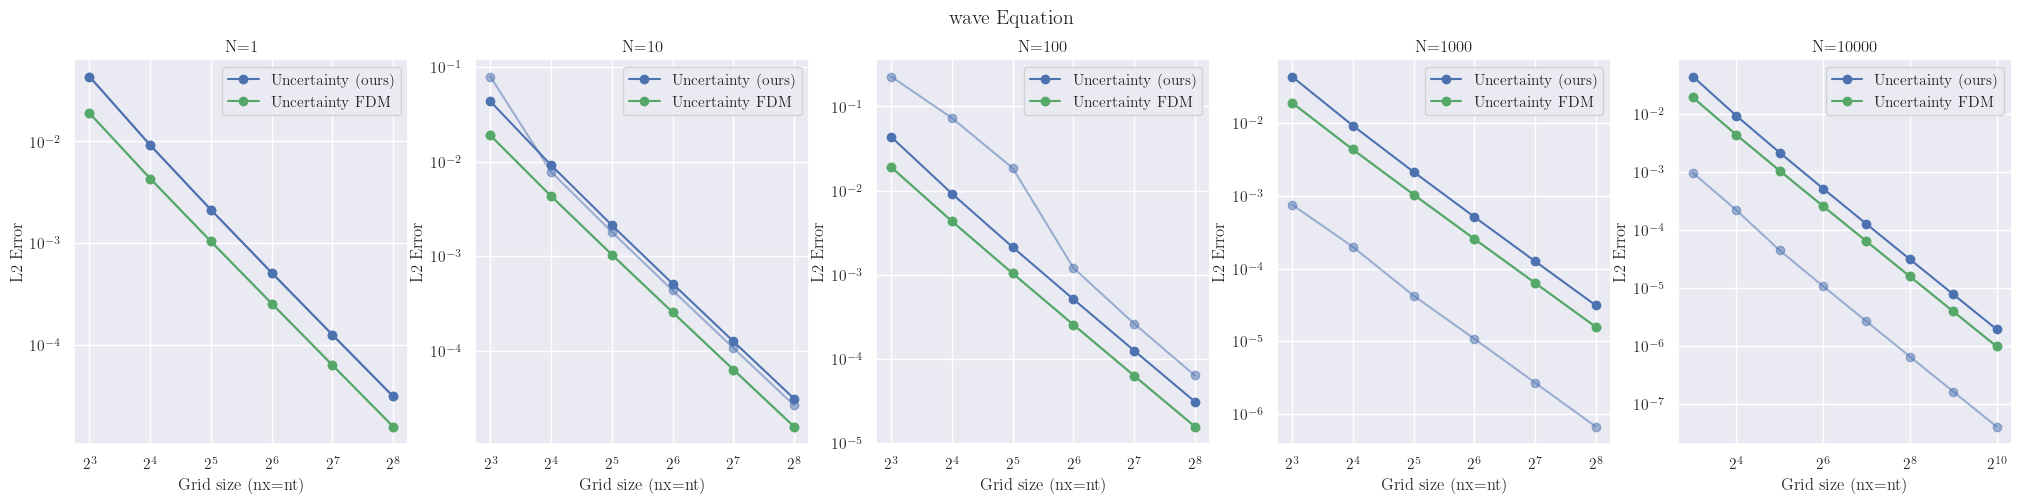

In [9]:
plot_results(df, "wave")

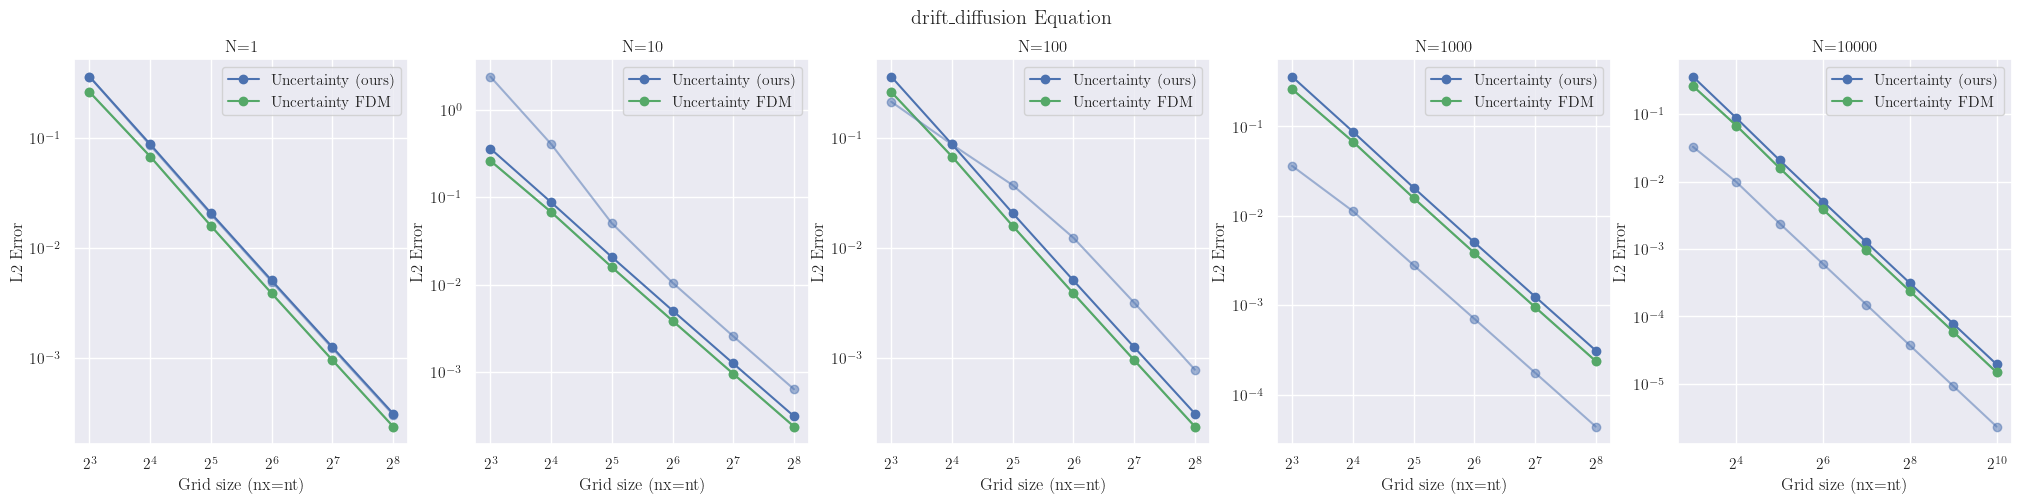

In [10]:
plot_results(df, "drift_diffusion")

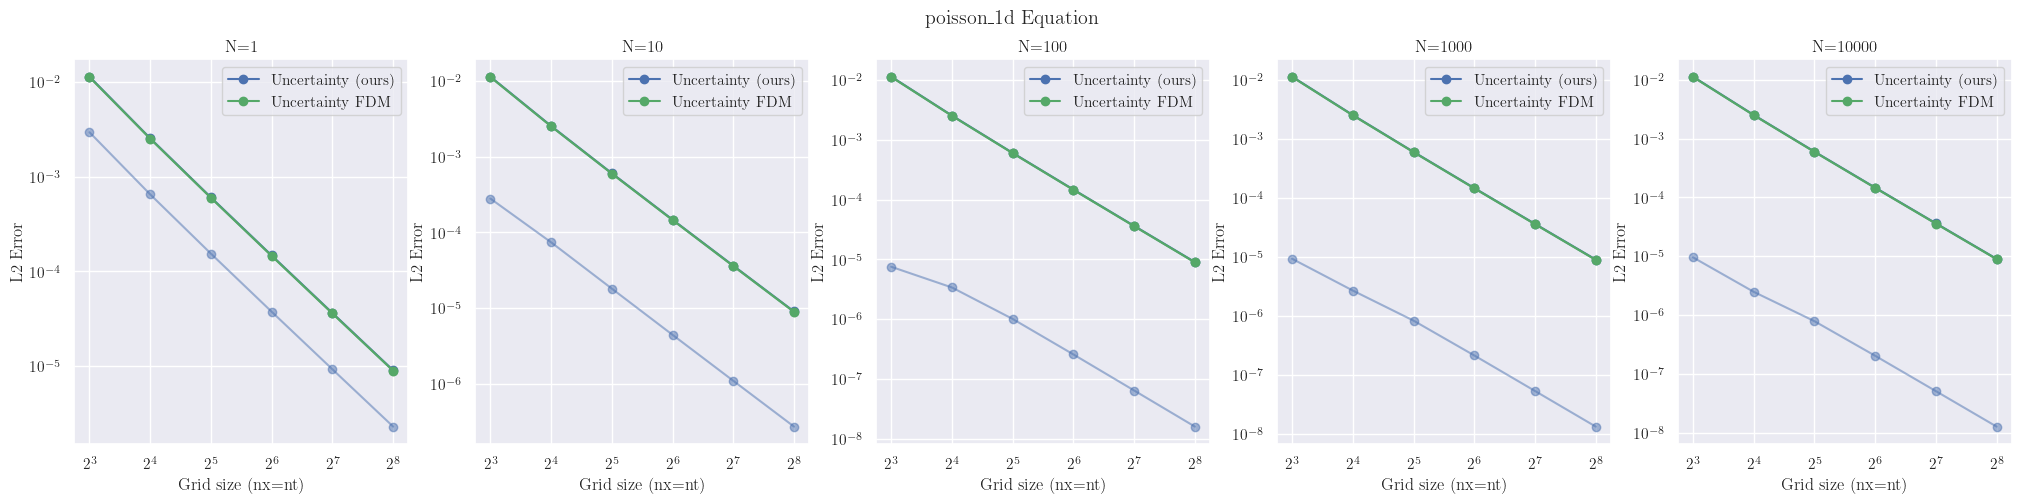

In [11]:
plot_results(df, "poisson_1d")

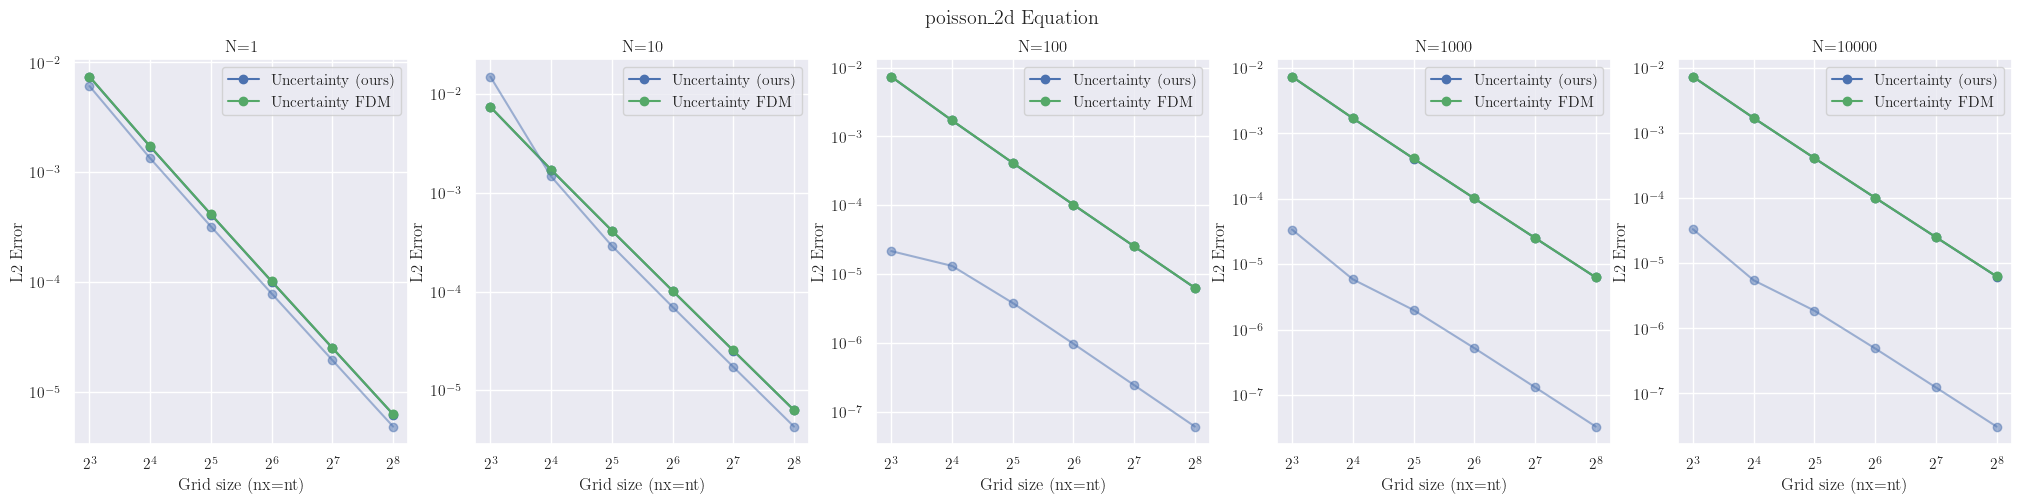

In [12]:
plot_results(df, "poisson_2d")